In [1]:
using Pkg
Pkg.add("Turing")
Pkg.add("StatsPlots")
Pkg.add("DifferentialEquations")
Pkg.add("LaTeXStrings")
Pkg.add("Plots")

using Turing
using DifferentialEquations

# Load StatsPlots for visualizations and diagnostics.
using StatsPlots
using Plots
using LaTeXStrings
using LinearAlgebra

# Set a seed for reproducibility.
using Random
Random.seed!(14);

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`


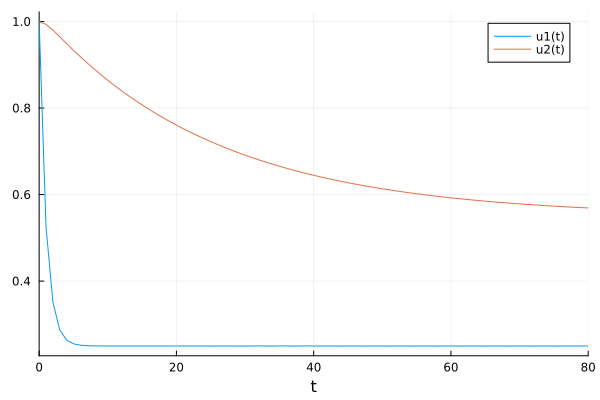

In [2]:
# Define model.
function TwoMetModel(du, u, p, t)
    # Model parameters.
    k₁, α₁, k₂, α₂ = p
    # Current state.
    x₁, x₂ = u

    # Evaluate differential equations.
    du[1] = -k₁ * (x₁ - α₁) # first metabolite
    du[2] = -k₂ * (x₂ - (1 - α₂) * x₁ - α₂) # second metabolite

    return nothing
end

# Define initial-value problem.
u0 = [1.0, 1.0]
p = [1.0, 0.25, 0.04, 0.4]
tspan = (0.0, 80.0)
prob = ODEProblem(TwoMetModel, u0, tspan, p)
True_sol = solve(prob,Tsit5(), saveat=1.0)

# Plot simulation.
plot(True_sol)


In [3]:
# Define the sets of time points
timepoints3 = [2, 2, 2, 36, 36, 36, 70, 70, 70]
timepoints5 = [2, 2, 2, 19, 19, 19, 36, 36, 36, 53, 53, 53, 70, 70, 70]
timepoints10 = [2, 2, 2, 10, 10, 10, 18, 18, 18, 26, 26, 26, 34, 34, 34, 42, 42, 42, 50, 50, 50, 58, 58, 58, 66, 66, 66, 74, 74, 74]


# Make noisy observations
sol3 = solve(prob, Tsit5(); saveat=timepoints3)
sol5 = solve(prob, Tsit5(); saveat=timepoints5)
sol10 = solve(prob, Tsit5(); saveat=timepoints10)
# noise level 2.5%
odedatatp3n2_5 = Array(sol3).*(1 .+ 0.025 * randn(size(Array(sol3))))
odedatatp5n2_5 = Array(sol5).*(1 .+ 0.025 * randn(size(Array(sol5))))
odedatatp10n2_5 = Array(sol10).*(1 .+ 0.025 * randn(size(Array(sol10))))
# noise level 5%
odedatatp3n5 = Array(sol3).*(1 .+ 0.05 * randn(size(Array(sol3))))
odedatatp5n5 = Array(sol5).*(1 .+ 0.05 * randn(size(Array(sol5))))
odedatatp10n5 = Array(sol10).*(1 .+ 0.05 * randn(size(Array(sol10))))
# noise level 10%
odedatatp3n10 = Array(sol3).*(1 .+ 0.1 * randn(size(Array(sol3))))
odedatatp5n10 = Array(sol5).*(1 .+ 0.1 * randn(size(Array(sol5))))
odedatatp10n10 = Array(sol10).*(1 .+ 0.1 * randn(size(Array(sol10))))


2×30 Matrix{Float64}:
 0.405934  0.352412  0.324368  0.221122  …  0.26016   0.243597  0.23545
 0.891809  0.969544  1.05085   0.860849     0.555151  0.575813  0.643185

In [4]:
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    framestyle=:box,
)
l2 = @layout [a{0.01h};b c d; e f g; h i j; k{0.1h}]

title = plot(title = L"Solutions and Noisy Data for $k_X \gg k_Y$", titlefontsize = 20, grid = false, 
    showaxis = false, bottom_margin = -40Plots.px)

# Plot simulation and noisy observations.
plot(solve(prob,Tsit5()); legend=false, title = "3 time points", ylabel = "2.5% noise", xlabel = L"$t$", 
    titlefontsize = 16)
plot1 = scatter!(sol3.t, odedatatp3n2_5'; color=[1 2], markerstrokecolor = [1 2], 
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, title = "5 time points", xlabel = L"$t$", 
    titlefontsize = 16)
plot2 = scatter!(sol5.t, odedatatp5n2_5'; color=[1 2], markerstrokecolor = [1 2], 
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, title = "10 time points", xlabel = L"$t$",
    titlefontsize = 16)
plot3 = scatter!(sol10.t, odedatatp10n2_5'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, ylabel = "5% noise", xlabel = L"$t$")
plot4 = scatter!(sol3.t, odedatatp3n5'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1],label="")

plot(solve(prob,Tsit5()); legend=false, xlabel = L"$t$")
plot5 = scatter!(sol5.t, odedatatp5n5'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, xlabel = L"$t$")
plot6 = scatter!(sol10.t, odedatatp10n5'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, ylabel = "10% noise", xlabel = L"$t$")
plot7 = scatter!(sol3.t, odedatatp3n10'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, xlabel = L"$t$",)
plot8 = scatter!(sol5.t, odedatatp5n10'; color=[1 2], markerstrokecolor = [1 2], 
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); legend=false, xlabel = L"$t$",)
plot9 = scatter!(sol10.t, odedatatp10n10'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label="")

plot(solve(prob,Tsit5()); label = [L"$\bar{x}\:(t)$" L"$\bar{y}\:(t)$"], legend = :top, legend_columns = 2)
ylims!(2.0,3.0)
plot10 = scatter!(sol10.t, odedatatp10n10'; color=[1 2], markerstrokecolor = [1 2],
    markerstrokealpha = [0.1 0.1], label=[L"$\bar{x}$ data" L"$\bar{y}$ data"], framestyle = :none,)

plot(title, plot1, plot2, plot3, plot4, plot5, plot6, plot7, plot8, plot9, plot10, layout=l2, thickness_scaling=1,
    legendfontsize=16, tickfontsize=10, guidefontsize = 16, size = (1000,1000))
savefig("2MFastSlowSolAndData.pdf")

"/home/bguppy/Paper code/2MFastSlowSolAndData.pdf"

In [5]:
@model function fitTMM(data, prob, timepoints)
    # Prior distributions.
    σ ~ InverseGamma(2, 3)
    #kₓ ~ truncated(Normal(0.5, 0.5); lower=0, upper=2)
    kₓ ~ Uniform(0,3)
    α ~ Uniform(0,1)
    k_y ~ Uniform(0,3)
    β ~ Uniform(0,1)

    # Simulate model. 
    p = [kₓ, α, k_y, β]
    predicted = solve(prob, Tsit5(); p=p, saveat=timepoints)

    # Observations.
    for i in 1:length(predicted)
        data[:, i] ~ MvNormal(predicted[i], σ^2 * I)
    end

    return nothing
end

model1 = fitTMM(odedatatp3n2_5, prob, timepoints3)
model2 = fitTMM(odedatatp5n2_5, prob, timepoints5)
model3 = fitTMM(odedatatp10n2_5, prob, timepoints10)
model4 = fitTMM(odedatatp3n5, prob, timepoints3)
model5 = fitTMM(odedatatp5n5, prob, timepoints5)
model6 = fitTMM(odedatatp10n5, prob, timepoints10)
model7 = fitTMM(odedatatp3n10, prob, timepoints3)
model8 = fitTMM(odedatatp5n10, prob, timepoints5)
model9 = fitTMM(odedatatp10n10, prob, timepoints10)

# Sample 3 independent chains with forward-mode automatic differentiation (the default).
#chain = sample(model, NUTS(0.65), MCMCSerial(), 2000, 3; progress=false)
chain1 = sample(model1, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain2 = sample(model2, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain3 = sample(model3, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain4 = sample(model4, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain5 = sample(model5, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain6 = sample(model6, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain7 = sample(model7, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain8 = sample(model8, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)
chain9 = sample(model9, NUTS(0.65), MCMCSerial(), 10000, 1; progress=false)

┌ Info: Found initial step size
└   ϵ = 0.8
┌ Info: Found initial step size
└   ϵ = 0.8
┌ Info: Found initial step size
└   ϵ = 0.3576171875000001
┌ Info: Found initial step size
└   ϵ = 0.8
┌ Info: Found initial step size
└   ϵ = 0.8
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.8
┌ Info: Found initial step size
└   ϵ = 0.4
┌ Info: Found initial step size
└   ϵ = 0.4


Chains MCMC chain (10000×17×1 Array{Float64, 3}):

Iterations        = 1001:1:11000
Number of chains  = 1
Samples per chain = 10000
Wall duration     = 16.23 seconds
Compute duration  = 16.23 seconds
parameters        = σ, kₓ, α, k_y, β
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

           σ    0.0795    0.0092    0.0001   6057.0681   6067.6361    0.9999   ⋯
          kₓ    1.3319    0.5445    0.0122   2914.3381   1803.5134    1.0007   ⋯
           α    0.2536    0.0151    0.0002   6091.4951   5965.8245    0.9999   ⋯
         k_y    0.0482    0.0161    0.0002   3551.5876   2731.5747    1.0004   ⋯
           β    0.4363    0.0672    0.0013   3784.53

In [6]:
[sum(chain1[:numerical_error]), sum(chain2[:numerical_error]), sum(chain3[:numerical_error]),
    sum(chain4[:numerical_error]), sum(chain5[:numerical_error]), sum(chain6[:numerical_error]),
    sum(chain7[:numerical_error]), sum(chain8[:numerical_error]), sum(chain9[:numerical_error])]

9-element Vector{Float64}:
 0.0
 0.0
 0.0
 1.0
 4.0
 1.0
 1.0
 2.0
 0.0

In [7]:
[mean(chain1[:acceptance_rate]), mean(chain2[:acceptance_rate]), mean(chain3[:acceptance_rate]),
    mean(chain4[:acceptance_rate]), mean(chain5[:acceptance_rate]), mean(chain6[:acceptance_rate]),
    mean(chain7[:acceptance_rate]), mean(chain8[:acceptance_rate]), mean(chain9[:acceptance_rate])]

9-element Vector{Float64}:
 0.7164445129583923
 0.7878329919415236
 0.8280901114256635
 0.8219550695578433
 0.6932810791530377
 0.7849462803898548
 0.7665238038918668
 0.6254296147096368
 0.8844258557521553

In [8]:
using DataFrames
# Convert chains into DataFrames
c1 = DataFrame(chain1)
c2 = DataFrame(chain2)
c3 = DataFrame(chain3)
c4 = DataFrame(chain4)
c5 = DataFrame(chain5)
c6 = DataFrame(chain6)
c7 = DataFrame(chain7)
c8 = DataFrame(chain8)
c9 = DataFrame(chain9)

Row,iteration,chain,σ,kₓ,α,k_y,β,lp,n_steps,is_accept,acceptance_rate,log_density,hamiltonian_energy,hamiltonian_energy_error,max_hamiltonian_energy_error,tree_depth,numerical_error,step_size,nom_step_size
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1001,1,0.0942577,1.18798,0.254234,0.0380946,0.383313,45.5209,7.0,1.0,0.963156,45.5209,-42.5264,-0.00120056,-0.137285,3.0,0.0,0.324384,0.324384
2,1002,1,0.0676004,1.0607,0.276267,0.0376474,0.360681,45.1071,15.0,1.0,0.990847,45.1071,-43.7179,0.0665359,-0.194344,4.0,0.0,0.324384,0.324384
3,1003,1,0.0998018,1.3343,0.247327,0.0346718,0.376185,44.1577,15.0,1.0,0.9803,44.1577,-42.438,-0.030763,-0.366678,3.0,0.0,0.324384,0.324384
4,1004,1,0.0875703,0.846324,0.247094,0.0376869,0.421279,46.84,15.0,1.0,0.985702,46.84,-42.8966,-0.112455,-0.175225,4.0,0.0,0.324384,0.324384
5,1005,1,0.0934167,1.128,0.25561,0.0418495,0.409557,46.1267,7.0,1.0,0.878022,46.1267,-44.9322,0.0602606,0.288116,3.0,0.0,0.324384,0.324384
6,1006,1,0.0654325,1.49096,0.256906,0.0541714,0.45709,46.0464,15.0,1.0,0.939267,46.0464,-42.7167,-0.028032,-0.686599,4.0,0.0,0.324384,0.324384
7,1007,1,0.0764576,1.072,0.244285,0.0634686,0.454033,45.962,7.0,1.0,0.637863,45.962,-42.6248,0.701383,1.07714,3.0,0.0,0.324384,0.324384
8,1008,1,0.0861378,1.39841,0.245018,0.0721021,0.482374,45.2618,7.0,1.0,1.0,45.2618,-43.3677,-0.237931,-0.821515,3.0,0.0,0.324384,0.324384
9,1009,1,0.0723121,0.85831,0.265985,0.0416524,0.4077,47.2317,15.0,1.0,0.99386,47.2317,-45.1509,-0.342678,-0.478139,4.0,0.0,0.324384,0.324384


In [9]:
Pkg.add("KernelDensity")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.9/Project.toml`
  No Changes to `~/.julia/environments/v1.9/Manifest.toml`


In [10]:
using KernelDensity
#Compute Mode for each chain
#chain 1
c1_kx = kde(c1[!, :kₓ])
imax = findmax(c1_kx.density)[2]
c1_kx_mode = c1_kx.x[imax]

c1_a = kde(c1[!, :α])
imax = findmax(c1_a.density)[2]
c1_a_mode = c1_a.x[imax]

c1_ky = kde(c1[!, :k_y])
imax = findmax(c1_ky.density)[2]
c1_ky_mode = c1_ky.x[imax]

c1_b = kde(c1[!, :β])
imax = findmax(c1_b.density)[2]
c1_b_mode = c1_b.x[imax]

#chain 2
c2_kx = kde(c2[!, :kₓ])
imax = findmax(c2_kx.density)[2]
c2_kx_mode = c2_kx.x[imax]

c2_a = kde(c2[!, :α])
imax = findmax(c2_a.density)[2]
c2_a_mode = c2_a.x[imax]

c2_ky = kde(c2[!, :k_y])
imax = findmax(c2_ky.density)[2]
c2_ky_mode = c2_ky.x[imax]

c2_b = kde(c2[!, :β])
imax = findmax(c2_b.density)[2]
c2_b_mode = c2_b.x[imax]

#chain 3
c3_kx = kde(c3[!, :kₓ])
imax = findmax(c3_kx.density)[2]
c3_kx_mode = c3_kx.x[imax]

c3_a = kde(c3[!, :α])
imax = findmax(c3_a.density)[2]
c3_a_mode = c3_a.x[imax]

c3_ky = kde(c3[!, :k_y])
imax = findmax(c3_ky.density)[2]
c3_ky_mode = c3_ky.x[imax]

c3_b = kde(c3[!, :β])
imax = findmax(c3_b.density)[2]
c3_b_mode = c3_b.x[imax]

# chain 4
c4_kx = kde(c4[!, :kₓ])
imax = findmax(c4_kx.density)[2]
c4_kx_mode = c4_kx.x[imax]

c4_a = kde(c4[!, :α])
imax = findmax(c4_a.density)[2]
c4_a_mode = c4_a.x[imax]

c4_ky = kde(c4[!, :k_y])
imax = findmax(c4_ky.density)[2]
c4_ky_mode = c4_ky.x[imax]

c4_b = kde(c4[!, :β])
imax = findmax(c4_b.density)[2]
c4_b_mode = c4_b.x[imax]

# chain 5 
c5_kx = kde(c5[!, :kₓ])
imax = findmax(c5_kx.density)[2]
c5_kx_mode = c5_kx.x[imax]

c5_a = kde(c5[!, :α])
imax = findmax(c5_a.density)[2]
c5_a_mode = c5_a.x[imax]

c5_ky = kde(c5[!, :k_y])
imax = findmax(c5_ky.density)[2]
c5_ky_mode = c5_ky.x[imax]

c5_b = kde(c5[!, :β])
imax = findmax(c5_b.density)[2]
c5_b_mode = c5_b.x[imax]

# chain 6
c6_kx = kde(c6[!, :kₓ])
imax = findmax(c6_kx.density)[2]
c6_kx_mode = c6_kx.x[imax]

c6_a = kde(c6[!, :α])
imax = findmax(c6_a.density)[2]
c6_a_mode = c6_a.x[imax]

c6_ky = kde(c6[!, :k_y])
imax = findmax(c6_ky.density)[2]
c6_ky_mode = c6_ky.x[imax]

c6_b = kde(c6[!, :β])
imax = findmax(c6_b.density)[2]
c6_b_mode = c6_b.x[imax]

# chain 7
c7_kx = kde(c7[!, :kₓ])
imax = findmax(c7_kx.density)[2]
c7_kx_mode = c7_kx.x[imax]

c7_a = kde(c7[!, :α])
imax = findmax(c7_a.density)[2]
c7_a_mode = c7_a.x[imax]

c7_ky = kde(c1[!, :k_y])
imax = findmax(c7_ky.density)[2]
c7_ky_mode = c7_ky.x[imax]

c7_b = kde(c7[!, :β])
imax = findmax(c7_b.density)[2]
c7_b_mode = c7_b.x[imax]

# chain 8 
c8_kx = kde(c8[!, :kₓ])
imax = findmax(c8_kx.density)[2]
c8_kx_mode = c8_kx.x[imax]

c8_a = kde(c8[!, :α])
imax = findmax(c8_a.density)[2]
c8_a_mode = c8_a.x[imax]

c8_ky = kde(c8[!, :k_y])
imax = findmax(c8_ky.density)[2]
c8_ky_mode = c8_ky.x[imax]

c8_b = kde(c8[!, :β])
imax = findmax(c8_b.density)[2]
c8_b_mode = c8_b.x[imax]

# chain 9
c9_kx = kde(c9[!, :kₓ])
imax = findmax(c9_kx.density)[2]
c9_kx_mode = c9_kx.x[imax]

c9_a = kde(c9[!, :α])
imax = findmax(c9_a.density)[2]
c9_a_mode = c9_a.x[imax]

c9_ky = kde(c9[!, :k_y])
imax = findmax(c9_ky.density)[2]
c9_ky_mode = c9_ky.x[imax]

c9_b = kde(c9[!, :β])
imax = findmax(c9_b.density)[2]
c9_b_mode = c9_b.x[imax]

0.4622104063423908

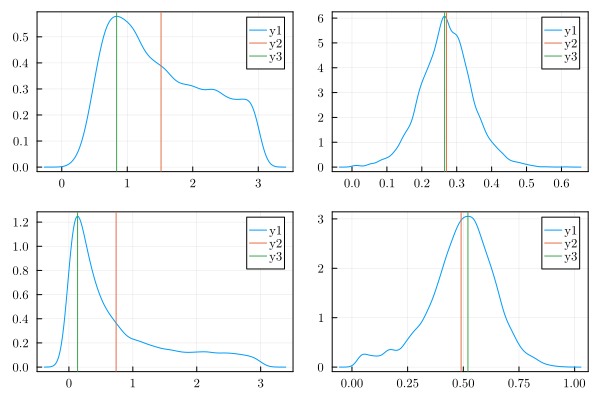

In [11]:
@df c1 density(:kₓ)
@df c1 vline!([mean(:kₓ)])
p1 = vline!([c1_kx_mode])

@df c1 density(:α)
@df c1 vline!([mean(:α)])
p2 = vline!([c1_a_mode])

@df c1 density(:k_y)
@df c1 vline!([mean(:k_y)])
p3 = vline!([c1_ky_mode])

@df c1 density(:β)
@df c1 vline!([mean(:β)])
p4 = vline!([c1_b_mode])

plot(p1, p2, p3, p4, layout = (2,2))

In [12]:
l4 = @layout [a b c]
l5 = @layout [a{0.001h};b;c; e{0.01h}]

# Violin plots for k_X and k_Y
titleD = plot(title = L"Posterior Distributions when $k_X \gg k_Y$", titlefontsize = 24, grid = false, 
   showaxis = false, bottom_margin = -50Plots.px, top_margin = -50Plots.px)

labels = ["3 time pts" "5 time pts" "10 time pts"]
violin(labels, [c1[!,:kₓ] c2[!,:kₓ] c3[!,:kₓ]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    ylabel = L"$k_X$ sample value", title = "2.5% noise", titlefontsize = 18)
hline!([p[1]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c1[!,:kₓ] c2[!,:kₓ] c3[!,:kₓ]], c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot1kx = scatter!(labels, [c1_kx_mode c2_kx_mode c3_kx_mode], c = [:black :black :black], legend = false)

violin(labels, [c4[!,:kₓ] c5[!,:kₓ] c6[!,:kₓ]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    title = "5% noise", titlefontsize = 18)
hline!([p[1]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c4[!,:kₓ] c5[!,:kₓ] c6[!,:kₓ]], c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot2kx =scatter!(labels, [c4_kx_mode c5_kx_mode c6_kx_mode], c = [:black :black :black], legend = false)

violin(labels, [c7[!,:kₓ] c8[!,:kₓ] c9[!,:kₓ]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    title = "10% noise", titlefontsize = 18)
hline!([p[1]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c7[!,:kₓ] c8[!,:kₓ] c9[!,:kₓ]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot3kx = scatter!(labels, [c7_kx_mode c8_kx_mode c9_kx_mode], c = [:black :black :black], legend = false)

vplotkx = plot(vplot1kx, vplot2kx, vplot3kx, layout = (1,3), yticks = [0, p[1], 1, 2, 3])

violin(labels, [c1[!,:k_y] c2[!,:k_y] c3[!,:k_y]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    ylabel = L"$k_Y$ sample value")
hline!([p[3]], c = :gray, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c1[!,:k_y] c2[!,:k_y] c3[!,:k_y]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot1ky = scatter!(labels, [c1_ky_mode c2_ky_mode c3_ky_mode], c = [:black :black :black], legend = false)

violin(labels, [c4[!,:k_y] c5[!,:k_y] c6[!,:k_y]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5])
hline!([p[3]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c4[!,:k_y] c5[!,:k_y] c6[!,:k_y]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot2ky = scatter!(labels, [c4_ky_mode c5_ky_mode c6_ky_mode], c = [:black :black :black], legend = false)

violin(labels, [c7[!,:k_y] c8[!,:k_y] c9[!,:k_y]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5])
hline!([p[3]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.1, 3.1))
boxplot!(labels, [c7[!,:k_y] c8[!,:k_y] c9[!,:k_y]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot3ky =scatter!(labels, [c7_ky_mode c8_ky_mode c9_ky_mode], c = [:black :black :black], legend = false)

vplotky = plot(vplot1ky, vplot2ky, vplot3ky, layout = l4, yticks = [p[3], 1, 2, 3])

scatter([1], [1], c = :black, label = "Estimate value ", ylims = (4.0,5.0), legend = :top,
    legend_columns = 2, legendfontsize = 14, thickness_scaling = 1)
legendplotkxky = hline!([p[1]], c = :gray, lw = 1.5, line = :dash, label = "True value", grid = false, 
    showaxis = false, thickness_scaling = 1)

plot(titleD, vplotkx, vplotky, legendplotkxky, layout = l5, guidefontsize = 18, ytickfontsize = 11,
    xrotation = 25, xtickfontsize = 14, size = (1000,1000), left_margin = 15Plots.px, bottom_margin = 15Plots.px)
savefig("2MFastSlowDenKXKY.pdf")

"/home/bguppy/Paper code/2MFastSlowDenKXKY.pdf"

In [18]:
l4 = @layout [a b c]
l5 = @layout [a{0.001h};b;c; e{0.01h}]

# Violin plots for alpha and beta
labels = ["3 time pts" "5 time pts" "10 time pts"]
violin(labels, [c1[!,:α] c2[!,:α] c3[!,:α]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    ylabel = L"$\alpha$ sample value", title = "2.5% noise", titlefontsize = 18)
hline!([p[2]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.05,1.05))
boxplot!(labels, [c1[!,:α] c2[!,:α] c3[!,:α]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot1a = scatter!(labels, [c1_a_mode c2_a_mode c3_a_mode], c = [:black :black :black], legend = false)

violin(labels, [c4[!,:α] c5[!,:α] c6[!,:α]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    title = "5% noise", titlefontsize = 18)
hline!([p[2]], c = :gray, lw = 1.5,  line = :dash, ylims = (-0.05,1.05))
boxplot!(labels, [c4[!,:α] c5[!,:α] c6[!,:α]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot2a = scatter!(labels, [c4_a_mode c5_a_mode c6_a_mode], c = [:black :black :black], legend = false)

violin(labels, [c7[!,:α] c8[!,:α] c9[!,:α]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    title = "10% noise", titlefontsize = 18)
hline!([p[2]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.05,1.05))
boxplot!(labels, [c7[!,:α] c8[!,:α] c9[!,:α]],  c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot3a = scatter!(labels, [c7_a_mode c8_a_mode c9_a_mode], c = [:black :black :black], legend = false)

vplota = plot(vplot1a, vplot2a, vplot3a, layout = l4, yticks = [0.0, p[2], 0.5, 0.75, 1.0])

violin(labels, [c1[!,:β] c2[!,:β] c3[!,:β]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5], 
    ylabel = L"$\beta$ sample value")
hline!([p[4]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.05, 1.05))
boxplot!(labels, [c1[!,:β] c2[!,:β] c3[!,:β]], c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot1b = scatter!(labels, [c1_b_mode c2_b_mode c3_b_mode], c = [:black :black :black], legend = false)

violin(labels, [c4[!,:β] c5[!,:β] c6[!,:β]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5])
hline!([p[4]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.05, 1.05))
boxplot!(labels, [c4[!,:β] c5[!,:β] c6[!,:β]], c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot2b = scatter!(labels, [c4_b_mode c5_b_mode c6_b_mode], c = [:black :black :black], legend = false)

violin(labels, [c7[!,:β] c8[!,:β] c9[!,:β]], line = 0, c = [3 4 5], fill = [0.5 0.5 0.5])
hline!([p[4]], c = :gray, lw = 1.5, line = :dash, ylims = (-0.05, 1.05))
boxplot!(labels, [c7[!,:β] c8[!,:β] c9[!,:β]], c = [3 4 5], line = [1.5 1.5 1.5], fill = [0.1 0.1 0.1], outliers = false)
vplot3b = scatter!(labels, [c7_b_mode c8_b_mode c9_b_mode], c = [:black :black :black], legend = false)

vplotb = plot(vplot1b, vplot2b, vplot3b, layout = l4, yticks = [0.0, 0.25, p[4], 0.5, 0.75, 1.0])

scatter([1], [1], c = :black, label = "Estimate value ", ylims = (4.0,5.0), legend = :top,
    legend_columns = 2, legendfontsize = 14, thickness_scaling = 1)
legendplotkxky = hline!([p[1]], c = :gray, lw = 1.5, line = :dash, label = "True value", grid = false, 
    showaxis = false, thickness_scaling = 1)

plot(titleD, vplota, vplotb, legendplotkxky, layout = l5, guidefontsize = 18, ytickfontsize = 11,
    xrotation = 25, xtickfontsize = 14, size = (1000,1000), left_margin = 15Plots.px, bottom_margin = 15Plots.px)
savefig("2MFastSlowDenAB.pdf")

"/home/bguppy/KFPcodes/2MFastSlowDenAB.pdf"

In [13]:
# get param values from distributions
p_mode1 = [c1_kx_mode c1_a_mode c1_ky_mode c1_b_mode]
p_upper1 = hcat([quantile(chain1[:kₓ], [0.025]), quantile(chain1[:α], [0.975]), quantile(chain1[:k_y], [0.025]), quantile(chain1[:β], [0.975])]...)
p_lower1 = hcat([quantile(chain1[:kₓ], [0.975]), quantile(chain1[:α], [0.025]), quantile(chain1[:k_y], [0.975]), quantile(chain1[:β], [0.025])]...)

p_mode2 = [c2_kx_mode c2_a_mode c2_ky_mode c2_b_mode]
p_upper2 = hcat([quantile(chain2[:kₓ], [0.025]), quantile(chain2[:α], [0.975]), quantile(chain2[:k_y], [0.025]), quantile(chain2[:β], [0.975])]...)
p_lower2 = hcat([quantile(chain2[:kₓ], [0.975]), quantile(chain2[:α], [0.025]), quantile(chain2[:k_y], [0.975]), quantile(chain2[:β], [0.025])]...)

p_mode3 = [c3_kx_mode c3_a_mode c3_ky_mode c3_b_mode]
p_upper3 = hcat([quantile(chain3[:kₓ], [0.025]), quantile(chain3[:α], [0.975]), quantile(chain3[:k_y], [0.025]), quantile(chain3[:β], [0.975])]...)
p_lower3 = hcat([quantile(chain3[:kₓ], [0.975]), quantile(chain3[:α], [0.025]), quantile(chain3[:k_y], [0.975]), quantile(chain3[:β], [0.025])]...)

p_mode4 = [c4_kx_mode c4_a_mode c4_ky_mode c1_b_mode]
p_upper4 = hcat([quantile(chain4[:kₓ], [0.025]), quantile(chain4[:α], [0.975]), quantile(chain4[:k_y], [0.025]), quantile(chain4[:β], [0.975])]...)
p_lower4 = hcat([quantile(chain4[:kₓ], [0.975]), quantile(chain4[:α], [0.025]), quantile(chain4[:k_y], [0.975]), quantile(chain4[:β], [0.025])]...)

p_mode5 = [c5_kx_mode c5_a_mode c5_ky_mode c5_b_mode]
p_upper5 = hcat([quantile(chain5[:kₓ], [0.025]), quantile(chain5[:α], [0.975]), quantile(chain5[:k_y], [0.025]), quantile(chain5[:β], [0.975])]...)
p_lower5 = hcat([quantile(chain5[:kₓ], [0.975]), quantile(chain5[:α], [0.025]), quantile(chain5[:k_y], [0.975]), quantile(chain5[:β], [0.025])]...)

p_mode6 = [c6_kx_mode c6_a_mode c6_ky_mode c6_b_mode]
p_upper6 = hcat([quantile(chain6[:kₓ], [0.025]), quantile(chain6[:α], [0.975]), quantile(chain6[:k_y], [0.025]), quantile(chain6[:β], [0.975])]...)
p_lower6 = hcat([quantile(chain6[:kₓ], [0.975]), quantile(chain6[:α], [0.025]), quantile(chain6[:k_y], [0.975]), quantile(chain6[:β], [0.025])]...)

p_mode7 = [c7_kx_mode c7_a_mode c7_ky_mode c7_b_mode]
p_upper7 = hcat([quantile(chain7[:kₓ], [0.025]), quantile(chain7[:α], [0.975]), quantile(chain7[:k_y], [0.025]), quantile(chain7[:β], [0.975])]...)
p_lower7 = hcat([quantile(chain7[:kₓ], [0.975]), quantile(chain7[:α], [0.025]), quantile(chain7[:k_y], [0.975]), quantile(chain7[:β], [0.025])]...)

p_mode8 = [c8_kx_mode c8_a_mode c8_ky_mode c8_b_mode]
p_upper8 = hcat([quantile(chain8[:kₓ], [0.025]), quantile(chain8[:α], [0.975]), quantile(chain8[:k_y], [0.025]), quantile(chain8[:β], [0.975])]...)
p_lower8 = hcat([quantile(chain8[:kₓ], [0.975]), quantile(chain8[:α], [0.025]), quantile(chain8[:k_y], [0.975]), quantile(chain8[:β], [0.025])]...)

p_mode9 = [c9_kx_mode c9_a_mode c9_ky_mode c9_b_mode]
p_upper9 = hcat([quantile(chain9[:kₓ], [0.025]), quantile(chain9[:α], [0.975]), quantile(chain9[:k_y], [0.025]), quantile(chain9[:β], [0.975])]...)
p_lower9 = hcat([quantile(chain9[:kₓ], [0.975]), quantile(chain9[:α], [0.025]), quantile(chain9[:k_y], [0.975]), quantile(chain9[:β], [0.025])]...)

1×4 Matrix{Float64}:
 2.78812  0.224042  0.0863601  0.277177

In [14]:
# solve with estimated  parameter values
sol_mode1 = solve(prob, Tsit5(); p=p_mode1, saveat=1.0)
sol_upper1 = solve(prob, Tsit5(); p=p_upper1, saveat=1.0)
sol_lower1 = solve(prob, Tsit5(); p=p_lower1, saveat=1.0)

sol_mode2 = solve(prob, Tsit5(); p=p_mode2, saveat=1.0)
sol_upper2 = solve(prob, Tsit5(); p=p_upper2, saveat=1.0)
sol_lower2 = solve(prob, Tsit5(); p=p_lower2, saveat=1.0)

sol_mode3 = solve(prob, Tsit5(); p=p_mode3, saveat=1.0)
sol_upper3 = solve(prob, Tsit5(); p=p_upper3, saveat=1.0)
sol_lower3 = solve(prob, Tsit5(); p=p_lower3, saveat=1.0)

sol_mode4 = solve(prob, Tsit5(); p=p_mode4, saveat=1.0)
sol_upper4 = solve(prob, Tsit5(); p=p_upper4, saveat=1.0)
sol_lower4 = solve(prob, Tsit5(); p=p_lower4, saveat=1.0)

sol_mode5 = solve(prob, Tsit5(); p=p_mode5, saveat=1.0)
sol_upper5 = solve(prob, Tsit5(); p=p_upper5, saveat=1.0)
sol_lower5 = solve(prob, Tsit5(); p=p_lower5, saveat=1.0)

sol_mode6 = solve(prob, Tsit5(); p=p_mode6, saveat=1.0)
sol_upper6 = solve(prob, Tsit5(); p=p_upper6, saveat=1.0)
sol_lower6 = solve(prob, Tsit5(); p=p_lower6, saveat=1.0)

sol_mode7 = solve(prob, Tsit5(); p=p_mode7, saveat=1.0)
sol_upper7 = solve(prob, Tsit5(); p=p_upper7, saveat=1.0)
sol_lower7 = solve(prob, Tsit5(); p=p_lower7, saveat=1.0)

sol_mode8 = solve(prob, Tsit5(); p=p_mode8, saveat=1.0)
sol_upper8 = solve(prob, Tsit5(); p=p_upper8, saveat=1.0)
sol_lower8 = solve(prob, Tsit5(); p=p_lower8, saveat=1.0)

sol_mode9 = solve(prob, Tsit5(); p=p_mode9, saveat=1.0)
sol_upper9 = solve(prob, Tsit5(); p=p_upper9, saveat=1.0)
sol_lower9 = solve(prob, Tsit5(); p=p_lower9, saveat=1.0)

# Unpack solutions
T_solX = permutedims(hcat(True_sol.u...))
mode_solX1 = permutedims(hcat(sol_mode1.u...))
upper_solX1 = permutedims(hcat(sol_upper1.u...))
lower_solX1 = permutedims(hcat(sol_lower1.u...))

mode_solX2 = permutedims(hcat(sol_mode2.u...))
upper_solX2 = permutedims(hcat(sol_upper2.u...))
lower_solX2 = permutedims(hcat(sol_lower2.u...))

mode_solX3 = permutedims(hcat(sol_mode3.u...))
upper_solX3 = permutedims(hcat(sol_upper3.u...))
lower_solX3 = permutedims(hcat(sol_lower3.u...))

mode_solX4 = permutedims(hcat(sol_mode4.u...))
upper_solX4 = permutedims(hcat(sol_upper4.u...))
lower_solX4 = permutedims(hcat(sol_lower4.u...))

mode_solX5 = permutedims(hcat(sol_mode5.u...))
upper_solX5 = permutedims(hcat(sol_upper5.u...))
lower_solX5 = permutedims(hcat(sol_lower5.u...))

mode_solX6 = permutedims(hcat(sol_mode6.u...))
upper_solX6 = permutedims(hcat(sol_upper6.u...))
lower_solX6 = permutedims(hcat(sol_lower6.u...))

mode_solX7 = permutedims(hcat(sol_mode7.u...))
upper_solX7 = permutedims(hcat(sol_upper7.u...))
lower_solX7 = permutedims(hcat(sol_lower7.u...))

mode_solX8 = permutedims(hcat(sol_mode8.u...))
upper_solX8 = permutedims(hcat(sol_upper8.u...))
lower_solX8 = permutedims(hcat(sol_lower8.u...))

mode_solX9 = permutedims(hcat(sol_mode9.u...))
upper_solX9 = permutedims(hcat(sol_upper9.u...))
lower_solX9 = permutedims(hcat(sol_lower9.u...))

81×2 Matrix{Float64}:
 1.0       1.0
 0.271789  0.968937
 0.226978  0.926046
 0.224222  0.885817
 0.224053  0.848863
 0.224042  0.814962
 0.22404   0.783867
 0.224045  0.755344
 0.224027  0.729181
 0.224022  0.705182
 0.224074  0.683168
 0.223852  0.662982
 0.22407   0.644455
 ⋮         
 0.223991  0.440616
 0.223969  0.440493
 0.224043  0.440377
 0.224131  0.440271
 0.224074  0.440177
 0.223983  0.440092
 0.223973  0.440012
 0.224056  0.439936
 0.224132  0.439867
 0.224062  0.439806
 0.223976  0.439751
 0.224068  0.439697

In [15]:
l = @layout [a b c; d e f; g h i; j{0.15h}]
    
# Plot for time points = 3 noise = 2.5% 
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), ylabel = "2.5% noise", xlabel = L"$t$",
    title = "3 time points", titlefontsize = 16)
plot!(sol_mode1.t, mode_solX1, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower1.t, lower_solX1[:,1], fillrange = upper_solX1[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower1.t, lower_solX1[:,2], fillrange = upper_solX1[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot1xy = scatter!(sol3.t, odedatatp3n2_5', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend=false)

# Plot for time points = 5 noise = 2.5%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$",
    title = "5 time points", titlefontsize = 16)
plot!(sol_mode2.t, mode_solX2, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower2.t, lower_solX2[:,1], fillrange = upper_solX2[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower2.t, lower_solX2[:,2], fillrange = upper_solX2[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot2xy = scatter!(sol5.t, odedatatp5n2_5', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend=false)

# Plot for time points = 10 noise = 2.5%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$",
    title = "10 time points", titlefontsize = 16)
plot!(sol_mode3.t, mode_solX3, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower3.t, lower_solX3[:,1], fillrange = upper_solX3[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower3.t, lower_solX3[:,2], fillrange = upper_solX3[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot3xy = scatter!(sol10.t, odedatatp10n2_5', c = [1 2],markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend=false)

# Plot for time points = 3 noise = 5%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), ylabel = "5% noise", xlabel = L"$t$")
plot!(sol_mode4.t, mode_solX4, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower4.t, lower_solX4[:,1], fillrange = upper_solX4[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower4.t, lower_solX4[:,2], fillrange = upper_solX4[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot4xy = scatter!(sol3.t, odedatatp3n5', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1], 
    legend = false)

# Plot for time points = 5 noise = 5%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$")
plot!(sol_mode5.t, mode_solX5, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower5.t, lower_solX5[:,1], fillrange = upper_solX5[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower5.t, lower_solX5[:,2], fillrange = upper_solX5[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot5xy = scatter!(sol5.t, odedatatp5n5', c = [1 2],markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend = false)

# Plot for time points = 10 noise = 5%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$")
plot!(sol_mode6.t, mode_solX6, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower6.t, lower_solX6[:,1], fillrange = upper_solX6[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower6.t, lower_solX6[:,2], fillrange = upper_solX6[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot6xy = scatter!(sol10.t, odedatatp10n5', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend = false)

# Plot for time points = 3 noise = 10%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), ylabel = "10% noise", xlabel = L"$t$")
plot!(sol_mode7.t, mode_solX7, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower7.t, lower_solX7[:,1], fillrange = upper_solX7[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower7.t, lower_solX7[:,2], fillrange = upper_solX7[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot7xy = scatter!(sol3.t, odedatatp3n10', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend = false)

# Plot for time points = 5 noise = 10%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$")
plot!(sol_mode8.t, mode_solX8, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower8.t, lower_solX8[:,1], fillrange = upper_solX8[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower8.t, lower_solX8[:,2], fillrange = upper_solX8[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot8xy = scatter!(sol5.t, odedatatp5n10', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend = false)

# Plot for time points = 10 noise = 10%
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], ylims = (0.0, 1.0), xlabel = L"$t$")
plot!(sol_mode9.t, mode_solX9, lw = [2 2], c = [1 2], line = [:dash :dash])   
plot!(sol_lower9.t, lower_solX9[:,1], fillrange = upper_solX9[:,1], fillalpha = 0.35, linealpha = 0, c = 1)
plot!(sol_lower9.t, lower_solX9[:,2], fillrange = upper_solX9[:,2], fillalpha = 0.35, linealpha = 0, c = 2)
plot9xy = scatter!(sol10.t, odedatatp10n10', c = [1 2], markerstrokecolor = [1 2], markerstrokealpha = [0.1 0.1],
    legend = false)

# This puts the legend on the bottom
plot(True_sol.t, T_solX, lw = [1 1], c = [1 2], label = [L"True $\bar{x}\:(t)$" L"True $\bar{y}\:(t)$"])
plot!(sol_mode9.t, mode_solX9, lw = [2 2], c = [1 2], line = [:dash :dash], label = [L"$\bar{x}\:(t)$ using param est." L"$\bar{y}\:(t)$ using param est."])   
plot!(sol_lower9.t, lower_solX9[:,1], fillrange = upper_solX9[:,1], fillalpha = 0.35, linealpha = 0, c = 1,
    label = "95% credible interval")
plot!(sol_lower9.t, lower_solX9[:,2], fillrange = upper_solX9[:,2], fillalpha = 0.35, linealpha = 0, c = 2,
    label = "95% credible interval")
ylims!(2,3)
plot10xy = scatter!(sol10.t, odedatatp10n10', c = [1 2], markerstrokecolor = [1 2], 
    markerstrokealpha = [0.1 0.1],label = [L"$\bar{x}$ data" L"$\bar{y}$ data"],
    framestyle = :none, legend = :top, legend_columns=2)
    
plot(plot1xy, plot2xy, plot3xy, plot4xy, plot5xy, plot6xy, plot7xy, plot8xy, plot9xy, plot10xy, guidefontsize = 16,
    layout = l, thickness_scaling=1, legendfontsize=16, tickfontsize=10, size=(1000,1000))
savefig("2MFastSlowBayesEstimXY.pdf")

"/home/bguppy/Paper code/2MFastSlowBayesEstimXY.pdf"